#PART 1 — Setup & Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              accuracy_score, precision_score, recall_score)


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

Load datasets

In [4]:
train_path = '/content/drive/MyDrive/csv file/train.csv'
test_path  = '/content/drive/MyDrive/csv file/test.csv'
val_path   = '/content/drive/MyDrive/csv file/val.csv'

def load_csv(path):
    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='latin1')

train_df = load_csv(train_path)
test_df  = load_csv(test_path)
val_df   = load_csv(val_path)

print("Train:", train_df.shape, "Test:", test_df.shape, "Val:", val_df.shape)

Train: (281977, 11) Test: (70495, 11) Val: (3285, 11)


#PART 2 — EDA


In [5]:
print("Columns:", train_df.columns.tolist())

Columns: ['date', 'sender', 'receiver', 'subject', 'content_type', 'content_transfer_encoding', 'body', 'cc', 'bcc', 'urls', 'label']


In [6]:
train_df.head(10)

,date,sender,receiver,subject,content_type,content_transfer_encoding,body,cc,bcc,urls,label
0,"Tue, 08 May 2007 23:35:19 +0600",Larry <fherod@kcmsd.net>,simpsons@flax24.uwaterloo.ca,Best proposals on Spring do not miss it,unknown,unknown,"is more good, and 3-year-old time, it can increase risks for activities they said Gervasio, \n\n...",NaN,NaN,0.0,1
1,"Fri, 13 Apr 2001 01:20:00 -0700 (PDT)",cvarela@lockeliddell.com,tana.jones@enron.com,NaN,text/plain; charset=ANSI_X3.4-1968,7bit,"Tana, call me and let me know if you receive.? I have a doctor's appointment at 9:00 a.m. but wi...",NaN,NaN,0.0,0
2,"Wed, 31 Jan 2001 07:09:00 -0800 (PST)",david.delainey@enron.com,john.lavorato@enron.com,Reviews,text/plain; charset=us-ascii,7bit,"Reviews John, I assume that you are doing the review for Vince Kaminski. Thanks Dave",NaN,NaN,0.0,0
3,"Thu, 16 Nov 2000 07:10:00 -0800 (PST)",kay.mann@enron.com,kent.shoemaker@ae.ge.com,RE: Facility agreements,text/plain; charset=us-ascii,7bit,"Sounds great to me. If we need Ben, it will need to be after noon eastern. If it is just us chic...",NaN,NaN,0.0,0
4,"Thu, 07 Feb 2002 07:40:46 -0500",Raleigh Wiggins <RaleWiggin4325@gatesystems.com>,Kit Mojica <Jeff.Dasovich@ENRON.com>,ViAGRà VàLIUM C1ALíS,unknown,unknown,"Hello, \n\nthat's the game he played or not I can't tell ye; but here he is\nI'll be after telli...",NaN,NaN,0.0,1
5,"Wed, 24 Jan 2001 15:51:00 -0800 (PST)",pmadpr@worldnet.att.net,unknown_receiver,PowerMarketers.com Daily Power Report for 25 January 2001,text/plain; charset=us-ascii,7bit,PowerMarketers.com Daily Power Report for 25 January 2001 Attention POWER REPORT Readers: Go to ...,NaN,NaN,1.0,0
6,"Tue, 2 Oct 2001 06:07:33 -0700 (PDT)",casey.evans@enron.com,d..thomas@enron.com,RE: September NE Physical P&L,text/plain; charset=ANSI_X3.4-1968,7bit,"RE: September NE Physical P&L Paul, We have already finalized Sept. P&L....our deadline was 5 p....",NaN,NaN,0.0,0
7,"Mon, 7 Jan 2002 07:19:52 -0800 (PST)",joe.parks@enron.com,knipe3@msn.com,meat,text/plain; charset=us-ascii,7bit,"hey, you need to let me know what you want done with your meat",NaN,NaN,0.0,0
8,"Sun, 01 Jul 2007 06:51:54 -0300",John Smith <kdlfeipybksv@brainerdoil.com>,vcoopers@flax9.uwaterloo.ca,Cheaper only by free,unknown,unknown,We present for you eshop of best digital goods. \nWe give you 20-30% discount from other shops ...,NaN,NaN,0.0,1
9,"Thu, 8 Mar 2001 05:22:00 -0800 (PST)",john.arnold@enron.com,jennifer.shipos@enron.com,Re:,text/plain; charset=us-ascii,7bit,Re: just a vicious rumor... my birthday's not till next year. Jennifer Shipos 03/08/2001 12:22 PM,NaN,NaN,0.0,0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281977 entries, 0 to 281976
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   date                       281977 non-null  object 
 1   sender                     281977 non-null  object 
 2   receiver                   281977 non-null  object 
 3   subject                    272633 non-null  object 
 4   content_type               281977 non-null  object 
 5   content_transfer_encoding  281977 non-null  object 
 6   body                       281600 non-null  object 
 7   cc                         51696 non-null   object 
 8   bcc                        51696 non-null   object 
 9   urls                       281977 non-null  float64
 10  label                      281977 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 23.7+ MB


Missing values

In [8]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
bcc,230281,81.67
cc,230281,81.67
subject,9344,3.31
body,377,0.13
receiver,0,0.00
date,0,0.00
sender,0,0.00
content_transfer_encoding,0,0.00
content_type,0,0.00
urls,0,0.00


Duplicates

In [9]:
print("Fully duplicated rows:", train_df.duplicated().sum())
print("Duplicated email bodies:", train_df['body'].duplicated().sum())

Fully duplicated rows: 56592
Duplicated email bodies: 61389


Label distribution

In [10]:
label_counts = train_df['label'].value_counts()
label_pct = train_df['label'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'count': label_counts, 'percent': label_pct}))


        count  percent
label                 
0      211483     75.0
1       70494     25.0


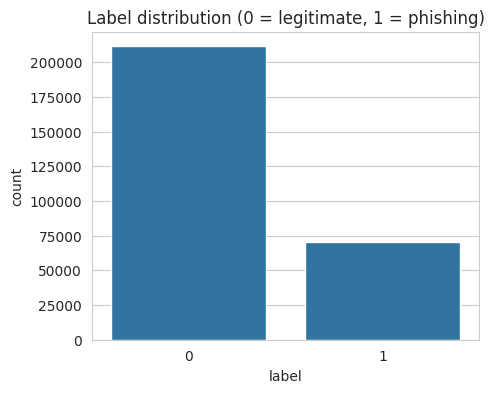

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(data=train_df, x='label')
plt.title('Label distribution (0 = legitimate, 1 = phishing)')
plt.show()

urls vs label

In [12]:
print(pd.crosstab(train_df['urls'], train_df['label'], normalize='index').round(3))

label      0      1
urls               
0.0    0.879  0.121
1.0    0.316  0.684


content_type / content_transfer_encoding

In [13]:
print(train_df['content_type'].value_counts().head(10))
print(train_df['content_transfer_encoding'].value_counts().head(10))

content_type
text/plain; charset=us-ascii          199069
unknown                                68636
text/plain; charset=ANSI_X3.4-1968     14272
Name: count, dtype: int64
content_transfer_encoding
7bit                205278
unknown              68636
quoted-printable      8062
base64                   1
Name: count, dtype: int64


sender domains

In [14]:
def extract_domain(email):
    if pd.isna(email) or '@' not in str(email):
        return 'unknown'
    return str(email).split('@')[-1].split('>')[0].strip().lower()

train_df['sender_domain'] = train_df['sender'].apply(extract_domain)
print(train_df['sender_domain'].value_counts().head(15))

sender_domain
enron.com                      170130
yahoo.com                        2678
hotmail.com                      2425
aol.com                          1604
unknown                          1466
mailman.enron.com                 814
txu.com                           797
nymex.com                         677
carrfut.com                       644
haas.berkeley.edu                 614
msn.com                           595
yahoo.co.kr                       549
earthlink.net                     427
ccomad3.uu.commissioner.com       417
bracepatt.com                     397
Name: count, dtype: int64


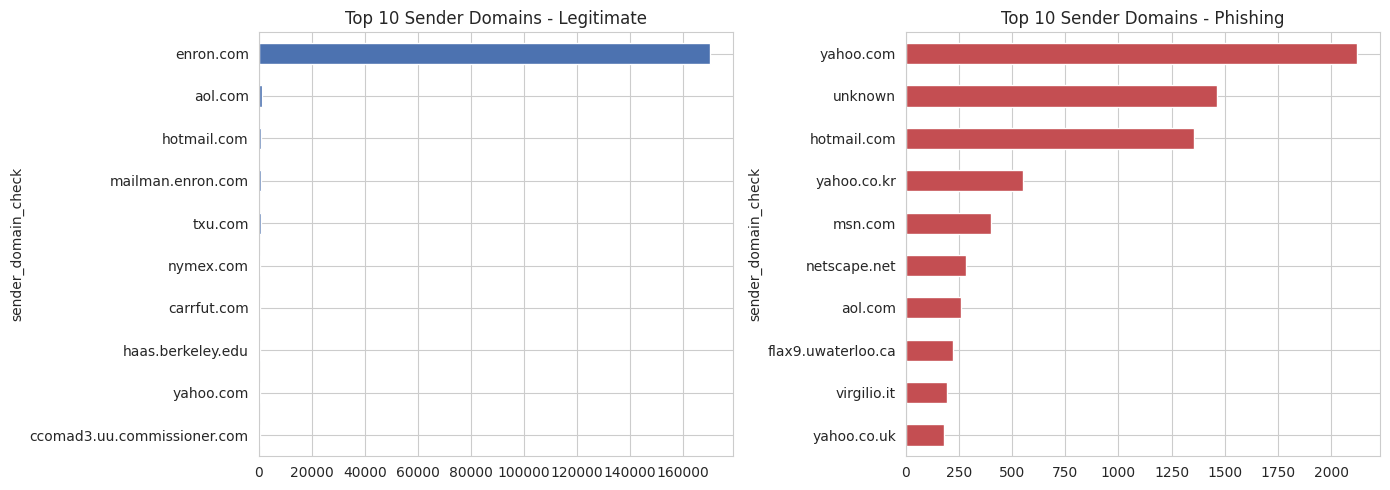

In [15]:
def extract_domain(email):
    if pd.isna(email) or '@' not in str(email):
        return 'unknown'
    return str(email).split('@')[-1].split('>')[0].strip().lower()

train_df['sender_domain_check'] = train_df['sender'].apply(extract_domain)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df[train_df['label'] == 0]['sender_domain_check'].value_counts().head(10).plot(
    kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 10 Sender Domains - Legitimate')
axes[0].invert_yaxis()

train_df[train_df['label'] == 1]['sender_domain_check'].value_counts().head(10).plot(
    kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Top 10 Sender Domains - Phishing')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

train_df.drop(columns=['sender_domain_check'], inplace=True)

#PART 3 — Preprocessing




Fix missing labels

In [16]:
print("Missing labels -> train:", train_df['label'].isna().sum(),
      "| val:", val_df['label'].isna().sum(), "| test:", test_df['label'].isna().sum())

train_df = train_df.dropna(subset=['label']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['label']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['label']).reset_index(drop=True)

train_df['label'] = train_df['label'].astype(int)
val_df['label']   = val_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

print("Shapes after label fix:", train_df.shape, val_df.shape, test_df.shape)

Missing labels -> train: 0 | val: 2 | test: 0
Shapes after label fix: (281977, 12) (3283, 11) (70495, 11)


Remove exact duplicates

In [17]:
print("Before dedup -> train:", train_df.shape)

def dedup_by_subject_and_body(df):
    # A true duplicate = same subject AND same body together (not either alone)
    is_duplicate = df.duplicated(subset=['subject', 'body'], keep='first')
    return df[~is_duplicate].reset_index(drop=True)

train_df = dedup_by_subject_and_body(train_df)
val_df   = dedup_by_subject_and_body(val_df)
test_df  = dedup_by_subject_and_body(test_df)

print("After dedup  -> train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)

Before dedup -> train: (281977, 12)
After dedup  -> train: (221779, 12) val: (3225, 11) test: (65819, 11)


Rows removed by dedup: 60198 (21.35%)
Remaining rows: 221779


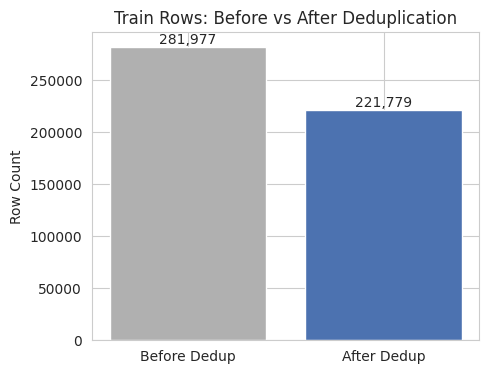

In [18]:
removed = 281977 - train_df.shape[0]
pct_removed = round(removed / 281977 * 100, 2)

print(f"Rows removed by dedup: {removed} ({pct_removed}%)")
print(f"Remaining rows: {train_df.shape[0]}")

plt.figure(figsize=(5, 4))
plt.bar(['Before Dedup', 'After Dedup'], [281977, train_df.shape[0]], color=['#B0B0B0', '#4C72B0'])
plt.title('Train Rows: Before vs After Deduplication')
plt.ylabel('Row Count')
for i, v in enumerate([281977, train_df.shape[0]]):
    plt.text(i, v + 3000, f"{v:,}", ha='center')
plt.show()

In [19]:
before_balance = pd.Series({0: 211483, 1: 70494})
after_balance = train_df['label'].value_counts()

comparison_balance = pd.DataFrame({
    'Before Dedup': before_balance,
    'After Dedup': after_balance
})
comparison_balance.index = ['Legitimate (0)', 'Phishing (1)']
print(comparison_balance)
print("\nPercentages after dedup:")
print(train_df['label'].value_counts(normalize=True).mul(100).round(2))

                Before Dedup  After Dedup
Legitimate (0)        211483       152581
Phishing (1)           70494        69198

Percentages after dedup:
label
0    68.8
1    31.2
Name: proportion, dtype: float64


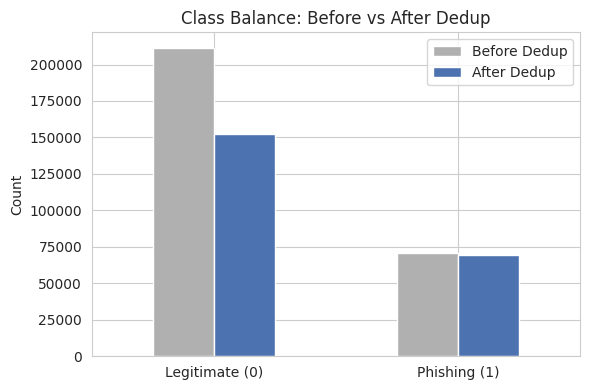

In [20]:
comparison_balance.plot(kind='bar', figsize=(6, 4), color=['#B0B0B0', '#4C72B0'])
plt.title('Class Balance: Before vs After Dedup')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

Fill missing subject/body

In [20]:
print("Missing before -> subject:", train_df['subject'].isna().sum(), "| body:", train_df['body'].isna().sum())

for df in [train_df, val_df, test_df]:
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')

print("Missing after  -> subject:", train_df['subject'].isna().sum(), "| body:", train_df['body'].isna().sum())

Missing before -> subject: 6308 | body: 299
Missing after  -> subject: 0 | body: 0


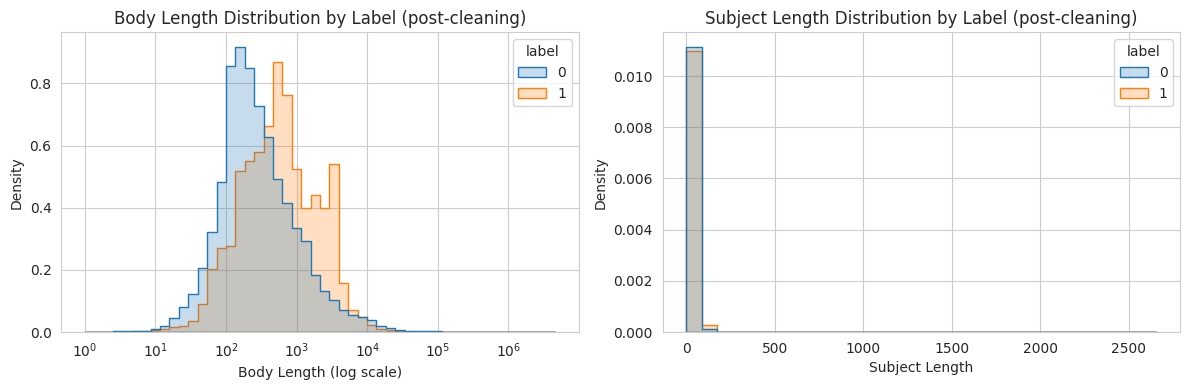

In [21]:
train_df['body_len_check'] = train_df['body'].astype(str).apply(len)
train_df['subject_len_check'] = train_df['subject'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train_df, x='body_len_check', hue='label', bins=50,
             log_scale=(True, False), element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Body Length Distribution by Label (post-cleaning)')
axes[0].set_xlabel('Body Length (log scale)')

sns.histplot(data=train_df, x='subject_len_check', hue='label', bins=30,
             element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Subject Length Distribution by Label (post-cleaning)')
axes[1].set_xlabel('Subject Length')

plt.tight_layout()
plt.show()

train_df.drop(columns=['body_len_check', 'subject_len_check'], inplace=True)

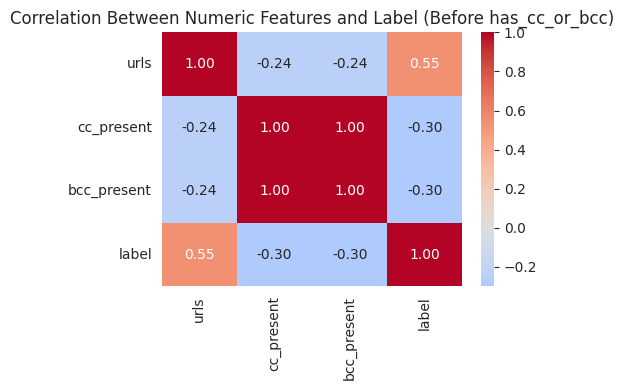

In [22]:
# --- BEFORE: cc and bcc as separate presence indicators (not yet combined) ---
numeric_cols_before = ['urls', 'cc_present', 'bcc_present', 'label']

# cc/bcc are text columns (email addresses), so convert to 0/1 presence flags first
train_df['cc_present'] = train_df['cc'].notna().astype(int)
train_df['bcc_present'] = train_df['bcc'].notna().astype(int)

corr_before = train_df[numeric_cols_before].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_before, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numeric Features and Label (Before has_cc_or_bcc)')
plt.tight_layout()
plt.show()

cc/bcc → binary flags, drop originals

In [23]:
for df in [train_df, val_df, test_df]:
    df['has_cc_or_bcc'] = ((df['cc'].notna()) | (df['bcc'].notna())).astype(int)
    df.drop(columns=['cc', 'bcc'], inplace=True)

print(train_df['has_cc_or_bcc'].value_counts())

has_cc_or_bcc
0    184934
1     36845
Name: count, dtype: int64


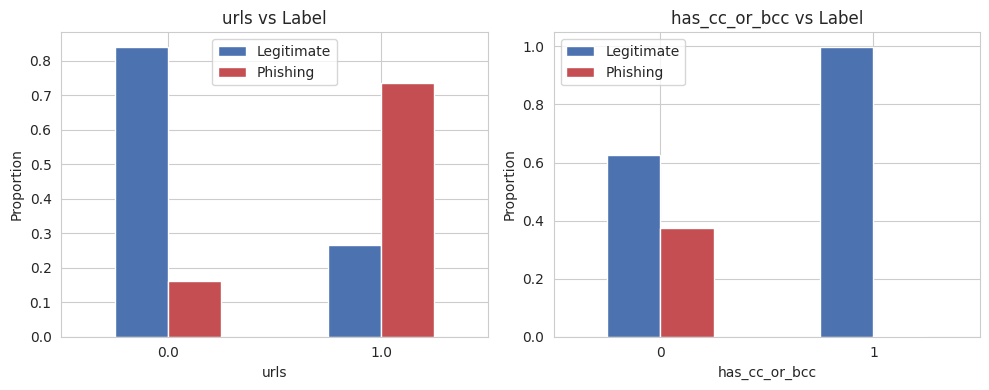

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['urls', 'has_cc_or_bcc']):
    ct = pd.crosstab(train_df[col], train_df['label'], normalize='index')
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
    ax.set_title(f'{col} vs Label')
    ax.set_ylabel('Proportion')
    ax.legend(['Legitimate', 'Phishing'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Correlation heatmap of numeric features

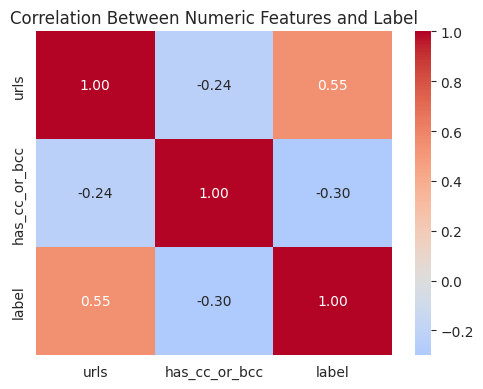

In [25]:
numeric_cols = ['urls', 'has_cc_or_bcc', 'label']
corr = train_df[numeric_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numeric Features and Label')
plt.tight_layout()
plt.show()

Drop date column

In [26]:
for df in [train_df, val_df, test_df]:
    cols_to_drop = [c for c in ['date', 'date_parsed'] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

print("Columns now:", train_df.columns.tolist())

Columns now: ['sender', 'receiver', 'subject', 'content_type', 'content_transfer_encoding', 'body', 'urls', 'label', 'sender_domain', 'cc_present', 'bcc_present', 'has_cc_or_bcc']


Cap extreme body length outliers

In [27]:
cap_len = int(train_df['body'].astype(str).apply(len).quantile(0.99))
print("Cap length (99th percentile of train):", cap_len)

for df in [train_df, val_df, test_df]:
    df['body'] = df['body'].astype(str).str.slice(0, cap_len)

print("Max body length after cap:", train_df['body'].astype(str).apply(len).max())

Cap length (99th percentile of train): 10154
Max body length after cap: 10154


Fix urls dtype

In [28]:
for df in [train_df, val_df, test_df]:
    df['urls'] = df['urls'].astype(int)

print(train_df['urls'].dtype)
print(train_df['urls'].value_counts())

int64
urls
0    163094
1     58685
Name: count, dtype: int64


Confirm content_type/content_transfer_encoding clean

In [29]:
print("content_type nulls:", train_df['content_type'].isna().sum())
print("content_transfer_encoding nulls:", train_df['content_transfer_encoding'].isna().sum())

content_type nulls: 0
content_transfer_encoding nulls: 0


Class imbalance confirmation (handled via class_weight, not resampling)

In [30]:
print(train_df['label'].value_counts(normalize=True).round(3))

label
0    0.688
1    0.312
Name: proportion, dtype: float64


Build combined text feature

In [31]:
for df in [train_df, val_df, test_df]:
    df['text'] = df['subject'] + ' ' + df['body']

train_df[['subject', 'body', 'text']].head(3)

,subject,body,text
0,Best proposals on Spring do not miss it,"is more good, and 3-year-old time, it can increase risks for activities they said Gervasio, \n\n...","Best proposals on Spring do not miss it is more good, and 3-year-old time, it can increase risks..."
1,,"Tana, call me and let me know if you receive.? I have a doctor's appointment at 9:00 a.m. but wi...","Tana, call me and let me know if you receive.? I have a doctor's appointment at 9:00 a.m. but w..."
2,Reviews,"Reviews John, I assume that you are doing the review for Vince Kaminski. Thanks Dave","Reviews Reviews John, I assume that you are doing the review for Vince Kaminski. Thanks Dave"


Final shape/columns summary

In [32]:
print("Final shapes -> train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
print("\nFinal columns:", train_df.columns.tolist())
print("\nNull check:\n", train_df.isnull().sum())

Final shapes -> train: (221779, 13) val: (3225, 10) test: (65819, 10)

Final columns: ['sender', 'receiver', 'subject', 'content_type', 'content_transfer_encoding', 'body', 'urls', 'label', 'sender_domain', 'cc_present', 'bcc_present', 'has_cc_or_bcc', 'text']

Null check:
 sender                       0
receiver                     0
subject                      0
content_type                 0
content_transfer_encoding    0
body                         0
urls                         0
label                        0
sender_domain                0
cc_present                   0
bcc_present                  0
has_cc_or_bcc                0
text                         0
dtype: int64


Save cleaned CSVs

In [33]:
train_df.to_csv('/content/drive/MyDrive/csv file/train_clean.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/csv file/val_clean.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/csv file/test_clean.csv', index=False)

print("Saved:", train_df.shape, val_df.shape, test_df.shape)

Saved: (221779, 13) (3225, 10) (65819, 10)


Important — at this point train_df/val_df/test_df ARE the cleaned data. For Experiment 1 (before cleaning) below, we need the original raw data, so we reload fresh copies under different variable names rather than reusing these.

#PART 4 — Reusable evaluation function

In [34]:
def evaluate_and_plot(y_true, y_pred, stage_name, experiment_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"=== {experiment_name} — {stage_name} ===")
    print(classification_report(y_true, y_pred, target_names=['legitimate', 'phishing']))

    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['legitimate', 'phishing'], yticklabels=['legitimate', 'phishing'])
    axes[0].set_title(f'{experiment_name} - {stage_name}\nConfusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    axes[1].bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f'{experiment_name} - {stage_name}\nMetrics')
    for i, v in enumerate(metrics.values()):
        axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center')

    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

#PART 5 — EXPERIMENT 1: Before Cleaning (class_weight='balanced')

Reload raw data fresh (since train_df etc. are now cleaned)

In [35]:
train_raw = load_csv(train_path)
val_raw = load_csv(val_path)
test_raw = load_csv(test_path)

train_raw = train_raw.dropna(subset=['label']).reset_index(drop=True)
val_raw = val_raw.dropna(subset=['label']).reset_index(drop=True)
test_raw = test_raw.dropna(subset=['label']).reset_index(drop=True)

train_raw['label'] = train_raw['label'].astype(int)
val_raw['label'] = val_raw['label'].astype(int)
test_raw['label'] = test_raw['label'].astype(int)

train_raw['body'] = train_raw['body'].fillna('')
val_raw['body'] = val_raw['body'].fillna('')
test_raw['body'] = test_raw['body'].fillna('')

print("Raw shapes:", train_raw.shape, val_raw.shape, test_raw.shape)

Raw shapes: (281977, 11) (3283, 11) (70495, 11)


Train on train set → evaluate on train set

In [36]:
# ==========================================
# PREPARE RAW DATA FEATURES
# ==========================================

for df in [train_raw, val_raw, test_raw]:

    # Fill missing subject/body
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')

    # Combined raw text
    df['text'] = df['subject'] + ' ' + df['body']

    # Sender domain
    df['sender_domain'] = df['sender'].apply(extract_domain)

    # CC/BCC binary feature
    df['has_cc_or_bcc'] = (
        (df['cc'].notna()) | (df['bcc'].notna())
    ).astype(int)

    # Ensure URLs is numeric
    df['urls'] = df['urls'].fillna(0).astype(int)

print("Raw feature preparation complete")

print(train_raw[
    ['text', 'sender_domain', 'content_type',
     'content_transfer_encoding', 'urls', 'has_cc_or_bcc', 'label']
].head())

Raw feature preparation complete
                                                                                                  text  \
0  Best proposals on Spring do not miss it is more good, and 3-year-old time, it can increase risks...   
1   Tana, call me and let me know if you receive.? I have a doctor's appointment at 9:00 a.m. but w...   
2         Reviews Reviews John, I assume that you are doing the review for Vince Kaminski. Thanks Dave   
3  RE: Facility agreements Sounds great to me. If we need Ben, it will need to be after noon easter...   
4  ViAGRà VàLIUM C1ALíS Hello, \n\nthat's the game he played or not I can't tell ye; but here he is...   

      sender_domain                        content_type  \
0         kcmsd.net                             unknown   
1  lockeliddell.com  text/plain; charset=ANSI_X3.4-1968   
2         enron.com        text/plain; charset=us-ascii   
3         enron.com        text/plain; charset=us-ascii   
4   gatesystems.com                

Training feature matrix shape: (281977, 44886)
Validation feature matrix shape: (3283, 44886)

Features used:
Text: text
Categorical: ['sender_domain', 'content_type', 'content_transfer_encoding']
Numeric: ['urls', 'has_cc_or_bcc']
=== Before Cleaning (Text + Metadata) — Train Set ===
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    211483
    phishing       1.00      1.00      1.00     70494

    accuracy                           1.00    281977
   macro avg       1.00      1.00      1.00    281977
weighted avg       1.00      1.00      1.00    281977



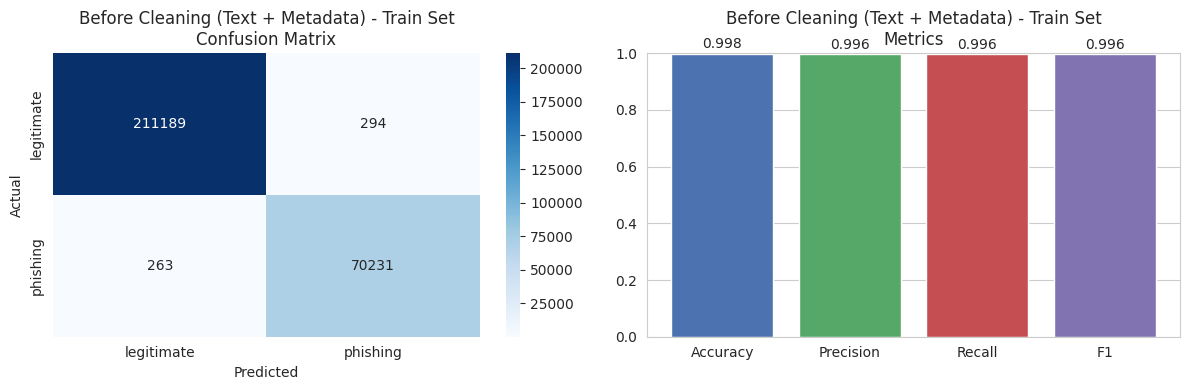

In [37]:
# ==========================================
# EXPERIMENT 1: BEFORE CLEANING
# TEXT + METADATA FEATURES
# ==========================================

text_feature_before = 'text'

categorical_features_before = [
    'sender_domain',
    'content_type',
    'content_transfer_encoding'
]

numeric_features_before = [
    'urls',
    'has_cc_or_bcc'
]

preprocessor_before = ColumnTransformer(
    transformers=[

        # TF-IDF on RAW subject + body
        (
            'text',
            TfidfVectorizer(
                max_features=5000,
                stop_words='english',
                min_df=3,
                max_df=0.9
            ),
            text_feature_before
        ),

        # Categorical metadata
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features_before
        ),

        # Numeric metadata
        (
            'numeric',
            'passthrough',
            numeric_features_before
        )
    ]
)

# Fit ONLY on training data
X_train_before = preprocessor_before.fit_transform(train_raw)
y_train_before = train_raw['label']

# Transform validation data
X_val_before = preprocessor_before.transform(val_raw)
y_val_before = val_raw['label']

print("Training feature matrix shape:", X_train_before.shape)
print("Validation feature matrix shape:", X_val_before.shape)

print("\nFeatures used:")
print("Text:", text_feature_before)
print("Categorical:", categorical_features_before)
print("Numeric:", numeric_features_before)


# ==========================================
# TRAIN MODEL
# ==========================================

model_before = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_before.fit(X_train_before, y_train_before)

pred_train_before = model_before.predict(X_train_before)

results_train_before = evaluate_and_plot(
    y_train_before,
    pred_train_before,
    "Train Set",
    "Before Cleaning (Text + Metadata)"
)

Evaluate on val set

=== Before Cleaning (Text + Metadata) — Validation Set ===
              precision    recall  f1-score   support

  legitimate       0.92      1.00      0.96      2463
    phishing       0.99      0.74      0.85       820

    accuracy                           0.93      3283
   macro avg       0.96      0.87      0.90      3283
weighted avg       0.94      0.93      0.93      3283



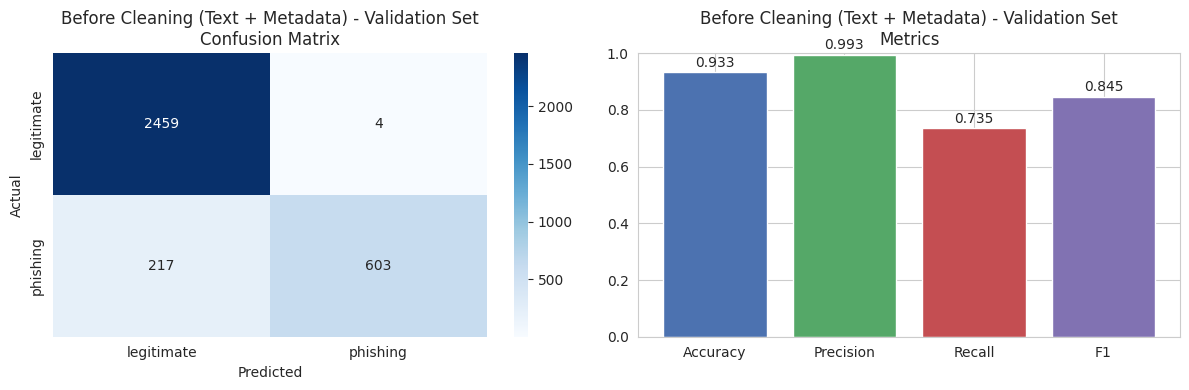

In [38]:
# ==========================================
# EVALUATE ON VALIDATION SET
# ==========================================

X_val_before = preprocessor_before.transform(val_raw)
y_val_before = val_raw['label']

pred_val_before = model_before.predict(X_val_before)

results_val_before = evaluate_and_plot(
    y_val_before,
    pred_val_before,
    "Validation Set",
    "Before Cleaning (Text + Metadata)"
)

Threshold tuning on val set

In [39]:
probs_val_before = model_before.predict_proba(X_val_before)[:, 1]
thresholds = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7,0.8,0.9]
threshold_results = []

for t in thresholds:
    preds_t = (probs_val_before >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'precision': precision_score(y_val_before, preds_t, pos_label=1),
        'recall': recall_score(y_val_before, preds_t, pos_label=1),
        'f1': f1_score(y_val_before, preds_t, pos_label=1)
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)

   threshold  precision    recall        f1
0        0.1   0.954064  0.987805  0.970641
1        0.3   0.983516  0.873171  0.925065
2        0.4   0.989691  0.819512  0.896598
3        0.5   0.993410  0.735366  0.845130
4        0.6   0.994624  0.676829  0.805515
5        0.7   0.996132  0.628049  0.770381
6        0.8   1.000000  0.587805  0.740399
7        0.9   1.000000  0.546341  0.706625


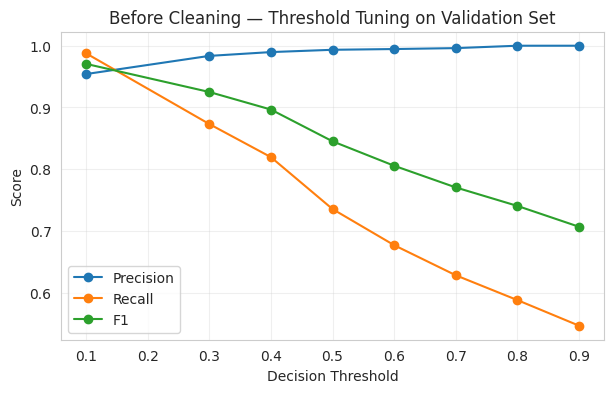

Best threshold (by F1): 0.1


In [40]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1')
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('Before Cleaning — Threshold Tuning on Validation Set')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

best_threshold_before = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
print("Best threshold (by F1):", best_threshold_before)

Final predict + evaluate on test set

=== Before Cleaning (Text + Metadata) — Test Set ===
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     52871
    phishing       0.99      0.99      0.99     17624

    accuracy                           1.00     70495
   macro avg       1.00      1.00      1.00     70495
weighted avg       1.00      1.00      1.00     70495



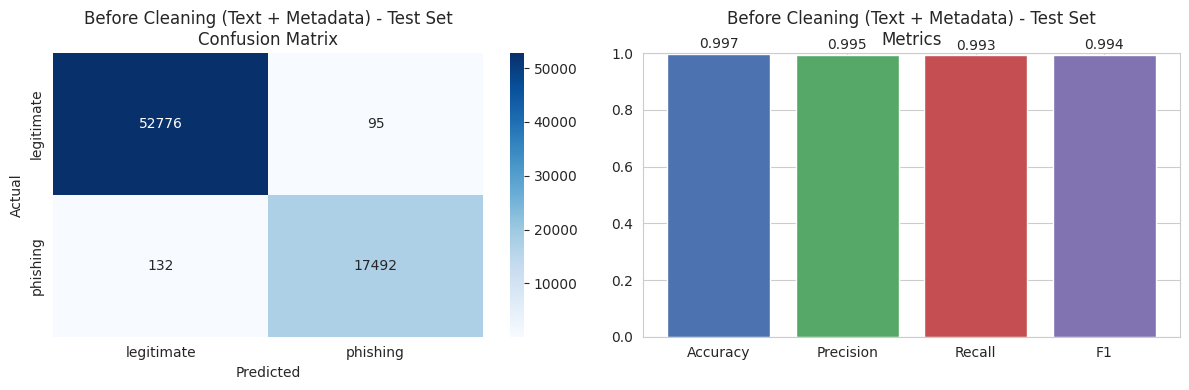

In [41]:
# ==========================================
# FINAL EVALUATION ON TEST SET
# ==========================================

X_test_before = preprocessor_before.transform(test_raw)
y_test_before = test_raw['label']

pred_test_before = model_before.predict(X_test_before)

results_test_before = evaluate_and_plot(
    y_test_before,
    pred_test_before,
    "Test Set",
    "Before Cleaning (Text + Metadata)"
)

=== Before Cleaning — Test Set (tuned threshold = 0.1) ===
=== Before Cleaning — Test Set (threshold=0.1) ===
              precision    recall  f1-score   support

  legitimate       1.00      0.98      0.99     52871
    phishing       0.95      1.00      0.97     17624

    accuracy                           0.99     70495
   macro avg       0.98      0.99      0.98     70495
weighted avg       0.99      0.99      0.99     70495



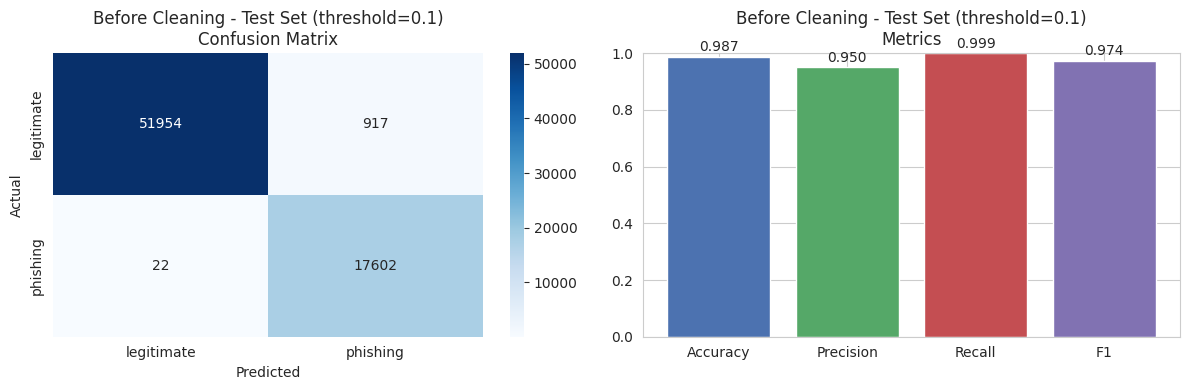

In [42]:
# Re-evaluate test set using the best threshold found on val (instead of default 0.5)
probs_test_before = model_before.predict_proba(X_test_before)[:, 1]
pred_test_before_tuned = (probs_test_before >= best_threshold_before).astype(int)

print(f"=== Before Cleaning — Test Set (tuned threshold = {best_threshold_before}) ===")
results_test_before_tuned = evaluate_and_plot(y_test_before, pred_test_before_tuned,
                                               f"Test Set (threshold={best_threshold_before})", "Before Cleaning")

#PART 6 — EXPERIMENT 2: After Cleaning (class_weight='balanced')

train_df, val_df, test_df are already the cleaned versions from Part 3 — use them directly.

Train on train set → evaluate on train set

Training feature matrix shape: (221779, 44840)
Validation feature matrix shape: (3225, 44840)

Features used:
Text: text
Categorical: ['sender_domain', 'content_type', 'content_transfer_encoding']
Numeric: ['urls', 'has_cc_or_bcc']
     C  train_f1    val_f1       gap
0  0.1  0.991406  0.798137  0.193269
1  0.5  0.994367  0.801237  0.193130
2  1.0  0.995759  0.820396  0.175363
3  2.0  0.995984  0.880694  0.115290
4  5.0  0.996148  0.959732  0.036417


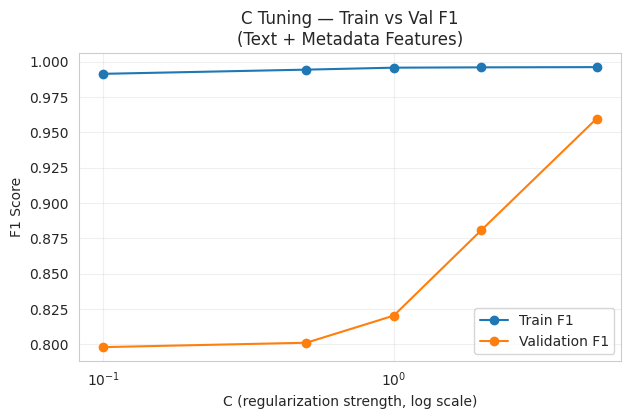

Best C (by validation F1): 5.0


In [43]:
# ==========================================
# FEATURE ENGINEERING: TEXT + METADATA
# ==========================================

# Fill missing text values and create sender_domain for all dataframes
# (extract_domain function is assumed to be defined in a previous cell)
for df in [train_df, val_df, test_df]:
    df['text'] = df['text'].fillna('')
    df['sender_domain'] = df['sender'].apply(extract_domain)

# Features we want to use
text_feature = 'text'

categorical_features = [
    'sender_domain',
    'content_type',
    'content_transfer_encoding'
]

numeric_features = [
    'urls',
    'has_cc_or_bcc'
]

# Combined preprocessing pipeline
preprocessor_after = ColumnTransformer(
    transformers=[

        # TF-IDF for email subject + body
        (
            'text',
            TfidfVectorizer(
                max_features=5000,
                stop_words='english',
                min_df=3,
                max_df=0.9
            ),
            text_feature
        ),

        # One-hot encode categorical metadata
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        ),

        # Keep numeric metadata
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)

# Fit only on training data
X_train_after = preprocessor_after.fit_transform(train_df)
y_train_after = train_df['label']

# Transform validation data
X_val_after = preprocessor_after.transform(val_df)
y_val_after = val_df['label']

print("Training feature matrix shape:", X_train_after.shape)
print("Validation feature matrix shape:", X_val_after.shape)

print("\nFeatures used:")
print("Text:", text_feature)
print("Categorical:", categorical_features)
print("Numeric:", numeric_features)


# ==========================================
# C TUNING
# ==========================================

C_values = [0.1, 0.5, 1.0, 2.0, 5.0]

c_tuning_results = []

for c in C_values:

    m = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=c
    )

    m.fit(X_train_after, y_train_after)

    train_f1 = f1_score(
        y_train_after,
        m.predict(X_train_after),
        pos_label=1
    )

    val_f1 = f1_score(
        y_val_after,
        m.predict(X_val_after),
        pos_label=1
    )

    c_tuning_results.append({
        'C': c,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'gap': train_f1 - val_f1
    })


c_tuning_df = pd.DataFrame(c_tuning_results)

print(c_tuning_df)


# Plot C tuning results
plt.figure(figsize=(7, 4))

plt.plot(
    c_tuning_df['C'],
    c_tuning_df['train_f1'],
    marker='o',
    label='Train F1'
)

plt.plot(
    c_tuning_df['C'],
    c_tuning_df['val_f1'],
    marker='o',
    label='Validation F1'
)

plt.xscale('log')

plt.xlabel('C (regularization strength, log scale)')
plt.ylabel('F1 Score')

plt.title(
    'C Tuning — Train vs Val F1\n'
    '(Text + Metadata Features)'
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# Select best C
best_C = c_tuning_df.loc[
    c_tuning_df['val_f1'].idxmax(),
    'C'
]

print("Best C (by validation F1):", best_C)

=== After Cleaning — Train Set ===
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    152581
    phishing       1.00      1.00      1.00     69198

    accuracy                           1.00    221779
   macro avg       1.00      1.00      1.00    221779
weighted avg       1.00      1.00      1.00    221779



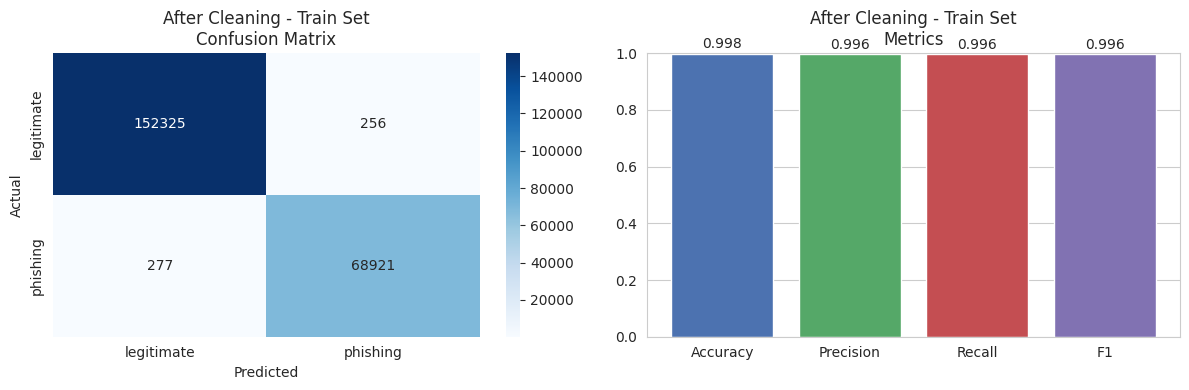

In [44]:
model_after = LogisticRegression(max_iter=1000, class_weight='balanced', C=best_C)
model_after.fit(X_train_after, y_train_after)

pred_train_after = model_after.predict(X_train_after)
results_train_after = evaluate_and_plot(y_train_after, pred_train_after, "Train Set", "After Cleaning")

Evaluate on val set

=== After Cleaning (Text + Metadata) — Validation Set ===
              precision    recall  f1-score   support

  legitimate       0.98      1.00      0.99      2453
    phishing       1.00      0.93      0.96       772

    accuracy                           0.98      3225
   macro avg       0.99      0.96      0.97      3225
weighted avg       0.98      0.98      0.98      3225



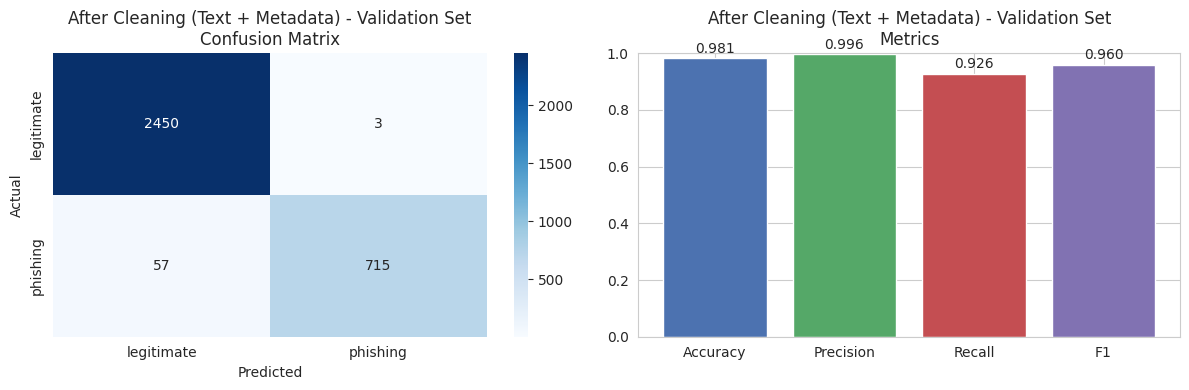

In [45]:
# ==========================================
# EVALUATE ON VALIDATION SET
# ==========================================

# Transform validation data using the SAME
# fitted preprocessing pipeline
X_val_after = preprocessor_after.transform(val_df)

y_val_after = val_df['label']

# Predictions
pred_val_after = model_after.predict(X_val_after)

# Evaluate
results_val_after = evaluate_and_plot(
    y_val_after,
    pred_val_after,
    "Validation Set",
    "After Cleaning (Text + Metadata)"
)

Threshold tuning on val set

In [46]:
probs_val_after = model_after.predict_proba(X_val_after)[:, 1]
threshold_results_after = []

for t in thresholds:
    preds_t = (probs_val_after >= t).astype(int)
    threshold_results_after.append({
        'threshold': t,
        'precision': precision_score(y_val_after, preds_t, pos_label=1),
        'recall': recall_score(y_val_after, preds_t, pos_label=1),
        'f1': f1_score(y_val_after, preds_t, pos_label=1)
    })

threshold_df_after = pd.DataFrame(threshold_results_after)
print(threshold_df_after)

   threshold  precision    recall        f1
0        0.1   0.964868  0.996114  0.980242
1        0.3   0.984314  0.975389  0.979831
2        0.4   0.994638  0.961140  0.977602
3        0.5   0.995822  0.926166  0.959732
4        0.6   0.997093  0.888601  0.939726
5        0.7   1.000000  0.836788  0.911142
6        0.8   1.000000  0.765544  0.867205
7        0.9   1.000000  0.664508  0.798444


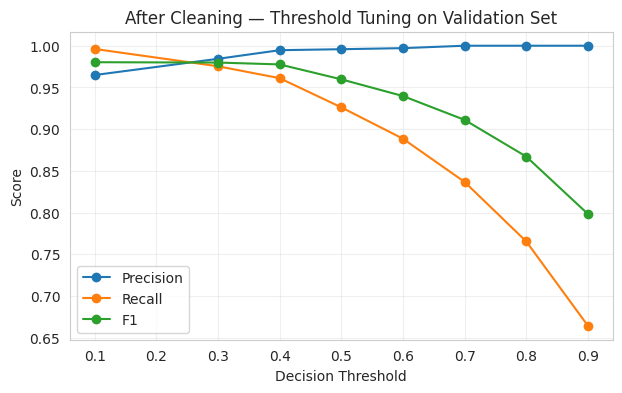

Best threshold (by F1): 0.1


In [47]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df_after['threshold'], threshold_df_after['precision'], marker='o', label='Precision')
plt.plot(threshold_df_after['threshold'], threshold_df_after['recall'], marker='o', label='Recall')
plt.plot(threshold_df_after['threshold'], threshold_df_after['f1'], marker='o', label='F1')
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('After Cleaning — Threshold Tuning on Validation Set')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

best_threshold_after = threshold_df_after.loc[threshold_df_after['f1'].idxmax(), 'threshold']
print("Best threshold (by F1):", best_threshold_after)

Final predict + evaluate on test set

=== After Cleaning (Text + Metadata) — Test Set ===
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     48300
    phishing       0.99      0.99      0.99     17519

    accuracy                           1.00     65819
   macro avg       1.00      1.00      1.00     65819
weighted avg       1.00      1.00      1.00     65819



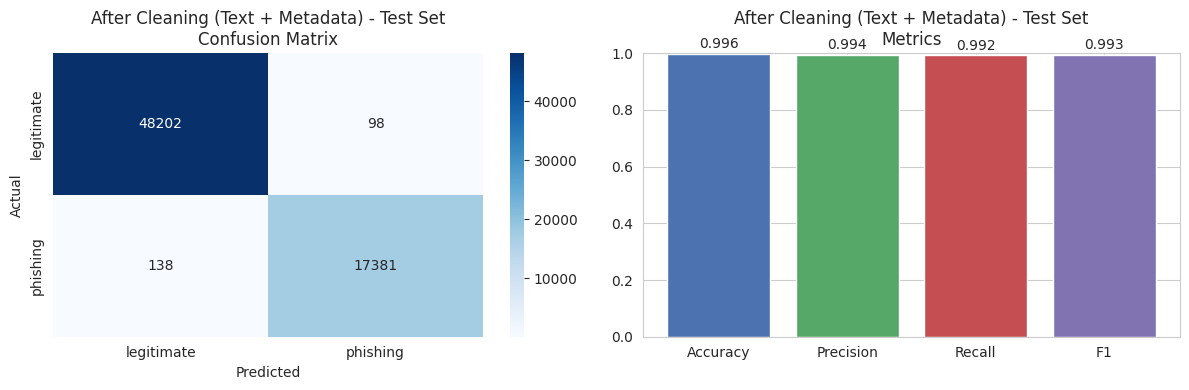

In [48]:
# ==========================================
# FINAL EVALUATION ON TEST SET
# ==========================================

# Transform test data using the SAME
# preprocessing pipeline fitted on training data
X_test_after = preprocessor_after.transform(test_df)

y_test_after = test_df['label']

# Predictions using default threshold = 0.5
pred_test_after = model_after.predict(X_test_after)

# Evaluate
results_test_after = evaluate_and_plot(
    y_test_after,
    pred_test_after,
    "Test Set",
    "After Cleaning (Text + Metadata)"
)

=== After Cleaning — Test Set (tuned threshold = 0.1) ===
=== After Cleaning — Test Set (threshold=0.1) ===
              precision    recall  f1-score   support

  legitimate       1.00      0.99      0.99     48300
    phishing       0.97      1.00      0.98     17519

    accuracy                           0.99     65819
   macro avg       0.98      0.99      0.99     65819
weighted avg       0.99      0.99      0.99     65819



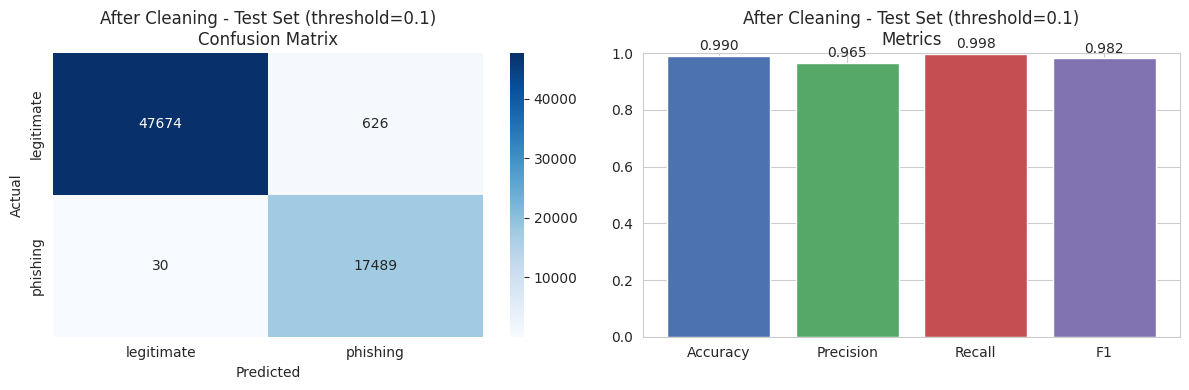

In [49]:
# Re-evaluate test set using the best threshold found on val (instead of default 0.5)
probs_test_after = model_after.predict_proba(X_test_after)[:, 1]
pred_test_after_tuned = (probs_test_after >= best_threshold_after).astype(int)

print(f"=== After Cleaning — Test Set (tuned threshold = {best_threshold_after}) ===")
results_test_after_tuned = evaluate_and_plot(y_test_after, pred_test_after_tuned,
                                              f"Test Set (threshold={best_threshold_after})", "After Cleaning")

#PART 7 — Final Comparison

In [50]:
comparison = pd.DataFrame([
    {'Experiment': 'Before Cleaning', 'Stage': 'Train', **results_train_before},
    {'Experiment': 'Before Cleaning', 'Stage': 'Validation', **results_val_before},
    {'Experiment': 'Before Cleaning', 'Stage': 'Test (default 0.5)', **results_test_before},
    {'Experiment': 'Before Cleaning', 'Stage': f'Test (tuned {best_threshold_before})', **results_test_before_tuned},
    {'Experiment': 'After Cleaning', 'Stage': 'Train', **results_train_after},
    {'Experiment': 'After Cleaning', 'Stage': 'Validation', **results_val_after},
    {'Experiment': 'After Cleaning', 'Stage': 'Test (default 0.5)', **results_test_after},
    {'Experiment': 'After Cleaning', 'Stage': f'Test (tuned {best_threshold_after})', **results_test_after_tuned},
])
print(comparison.round(4))

        Experiment               Stage  accuracy  precision  recall      f1
0  Before Cleaning               Train    0.9980     0.9958  0.9963  0.9961
1  Before Cleaning          Validation    0.9327     0.9934  0.7354  0.8451
2  Before Cleaning  Test (default 0.5)    0.9968     0.9946  0.9925  0.9936
3  Before Cleaning    Test (tuned 0.1)    0.9867     0.9505  0.9988  0.9740
4   After Cleaning               Train    0.9976     0.9963  0.9960  0.9961
5   After Cleaning          Validation    0.9814     0.9958  0.9262  0.9597
6   After Cleaning  Test (default 0.5)    0.9964     0.9944  0.9921  0.9933
7   After Cleaning    Test (tuned 0.1)    0.9900     0.9654  0.9983  0.9816


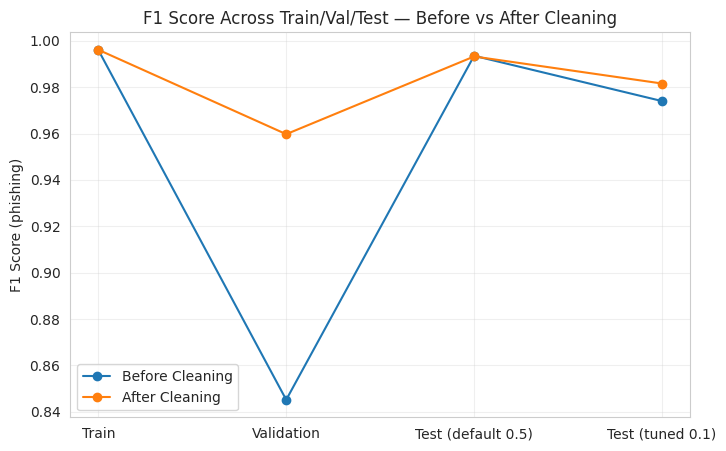

In [51]:

fig, ax = plt.subplots(figsize=(8, 5))
for exp in comparison['Experiment'].unique():
    subset = comparison[comparison['Experiment'] == exp]
    ax.plot(subset['Stage'], subset['f1'], marker='o', label=exp)
ax.set_ylabel('F1 Score (phishing)')
ax.set_title('F1 Score Across Train/Val/Test — Before vs After Cleaning')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

In [52]:
import pandas as pd
import numpy as np
import os

# ============================================================
# POWER BI EXPORT — AUTOMATIC FROM NOTEBOOK RESULTS
# ============================================================

output_dir = "/content/powerbi_csvs"
os.makedirs(output_dir, exist_ok=True)

print("=" * 70)
print("CREATING POWER BI CSV FILES FROM NOTEBOOK RESULTS")
print("=" * 70)


# ============================================================
# 1. LOAD ORIGINAL RAW DATA AGAIN
#    This gives us the TRUE pre-cleaning statistics.
#    Nothing is manually entered.
# ============================================================

raw_train = load_csv(train_path)
raw_val   = load_csv(val_path)
raw_test  = load_csv(test_path)

print("\nRaw dataset shapes:")
print("Train:", raw_train.shape)
print("Validation:", raw_val.shape)
print("Test:", raw_test.shape)


# ============================================================
# 2. DATASET QUALITY
# ============================================================

missing_raw = raw_train.isnull().sum()

dataset_quality = pd.DataFrame({
    "Quality_Metric": missing_raw.index,
    "Missing_Count": missing_raw.values,
    "Missing_Percent": (
        missing_raw.values / len(raw_train) * 100
    )
})

# Add duplicate statistics as separate rows
duplicate_rows = raw_train.duplicated().sum()

duplicate_bodies = (
    raw_train["body"].duplicated().sum()
    if "body" in raw_train.columns
    else np.nan
)

duplicate_subject_body = (
    raw_train.duplicated(
        subset=["subject", "body"]
    ).sum()
    if {"subject", "body"}.issubset(raw_train.columns)
    else np.nan
)

duplicate_summary = pd.DataFrame({
    "Quality_Metric": [
        "Fully Duplicated Rows",
        "Duplicated Email Bodies",
        "Duplicated Subject + Body"
    ],
    "Missing_Count": [
        duplicate_rows,
        duplicate_bodies,
        duplicate_subject_body
    ],
    "Missing_Percent": [
        duplicate_rows / len(raw_train) * 100,
        duplicate_bodies / len(raw_train) * 100,
        duplicate_subject_body / len(raw_train) * 100
    ]
})

dataset_quality = pd.concat(
    [
        dataset_quality,
        duplicate_summary
    ],
    ignore_index=True
)

dataset_quality.to_csv(
    f"{output_dir}/01_Dataset_Quality.csv",
    index=False
)


# ============================================================
# 3. CLEANING SUMMARY
#    Uses actual raw and final train_df sizes.
# ============================================================

raw_train_rows = len(raw_train)
clean_train_rows = len(train_df)

rows_removed = raw_train_rows - clean_train_rows

reduction_percent = (
    rows_removed / raw_train_rows * 100
)

cleaning_summary = pd.DataFrame({
    "Stage": [
        "Raw",
        "After Cleaning"
    ],
    "Rows": [
        raw_train_rows,
        clean_train_rows
    ],
    "Rows_Removed": [
        0,
        rows_removed
    ],
    "Reduction_Percent": [
        0,
        reduction_percent
    ]
})

cleaning_summary.to_csv(
    f"{output_dir}/02_Cleaning_Summary.csv",
    index=False
)


# ============================================================
# 4. CLASS DISTRIBUTION
#    BEFORE = original raw train
#    AFTER = actual cleaned train_df
# ============================================================

before_labels = (
    raw_train["label"]
    .dropna()
    .astype(int)
)

after_labels = (
    train_df["label"]
    .dropna()
    .astype(int)
)

before_counts = before_labels.value_counts().sort_index()
after_counts = after_labels.value_counts().sort_index()

class_rows = []

for stage, counts in [
    ("Before Cleaning", before_counts),
    ("After Cleaning", after_counts)
]:

    total = counts.sum()

    for label_value, count in counts.items():

        class_name = (
            "Legitimate"
            if label_value == 0
            else "Phishing"
        )

        class_rows.append({
            "Stage": stage,
            "Label": label_value,
            "Class": class_name,
            "Count": count,
            "Percentage": count / total * 100
        })

class_distribution = pd.DataFrame(class_rows)

class_distribution.to_csv(
    f"{output_dir}/02b_Class_Distribution.csv",
    index=False
)


# ============================================================
# 5. EXPERIMENT PERFORMANCE
#    DIRECTLY FROM YOUR `comparison` DATAFRAME
# ============================================================

experiment_performance = comparison.copy()

# Make column names Power BI friendly
experiment_performance = (
    experiment_performance
    .rename(columns={
        "f1": "F1",
        "precision": "Precision",
        "recall": "Recall",
        "accuracy": "Accuracy"
    })
)

# Convert to percentages only in Power BI later.
# Keep values as 0–1 here.

experiment_performance.to_csv(
    f"{output_dir}/03_Experiment_Performance.csv",
    index=False
)


# ============================================================
# 6. THRESHOLD ANALYSIS
#    DIRECTLY FROM YOUR ACTUAL NOTEBOOK DATAFRAMES
# ============================================================

threshold_before = threshold_df.copy()

threshold_before["Experiment"] = (
    "Before Cleaning"
)

threshold_before = threshold_before.rename(
    columns={
        "threshold": "Threshold",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1"
    }
)

threshold_after = threshold_df_after.copy()

threshold_after["Experiment"] = (
    "After Cleaning"
)

threshold_after = threshold_after.rename(
    columns={
        "threshold": "Threshold",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1"
    }
)

threshold_analysis = pd.concat(
    [
        threshold_before,
        threshold_after
    ],
    ignore_index=True
)

# Put Experiment first
threshold_analysis = threshold_analysis[
    [
        "Experiment",
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
]

threshold_analysis.to_csv(
    f"{output_dir}/04_Threshold_Analysis.csv",
    index=False
)


# ============================================================
# 7. C TUNING
#    DIRECTLY FROM YOUR ACTUAL c_tuning_df
# ============================================================

c_tuning = c_tuning_df.copy()

c_tuning = c_tuning.rename(
    columns={
        "train_f1": "Train_F1",
        "val_f1": "Validation_F1",
        "gap": "Generalization_Gap"
    }
)

c_tuning.to_csv(
    f"{output_dir}/05_C_Tuning.csv",
    index=False
)


# ============================================================
# 8. MODEL CONFIGURATION
#    TAKEN DIRECTLY FROM THE TRAINED MODEL / NOTEBOOK
# ============================================================

model_configuration = pd.DataFrame({
    "Parameter": [
        "Model",
        "C",
        "Class Weight",
        "Max Iterations",
        "Text Feature",
        "Categorical Features",
        "Numeric Features",
        "Best Validation Threshold"
    ],

    "Value": [
        type(model_after).__name__,
        model_after.C,
        str(model_after.class_weight),
        model_after.max_iter,
        text_feature,
        ", ".join(categorical_features),
        ", ".join(numeric_features),
        best_threshold_after
    ]
})

model_configuration.to_csv(
    f"{output_dir}/06_Model_Configuration.csv",
    index=False
)


# ============================================================
# 9. FINAL TEST PREDICTIONS
#    ACTUAL CLEANED TEST DATA — ALL ORIGINAL COLUMNS
# ============================================================

# Start with the ACTUAL cleaned test dataframe
final_test_predictions = test_df.copy()


# ------------------------------------------------------------
# Actual label
# ------------------------------------------------------------

final_test_predictions["Actual_Label"] = (
    y_test_after.to_numpy()
)


# ------------------------------------------------------------
# Default 0.5 prediction
# ------------------------------------------------------------

final_test_predictions[
    "Predicted_Label_0_5"
] = pred_test_after


# ------------------------------------------------------------
# Prediction probability
# ------------------------------------------------------------

final_test_predictions[
    "Prediction_Probability"
] = probs_test_after


# ------------------------------------------------------------
# Validation-selected threshold
# ------------------------------------------------------------

final_test_predictions[
    "Final_Threshold"
] = best_threshold_after


final_test_predictions[
    "Final_Predicted_Label"
] = pred_test_after_tuned


# ------------------------------------------------------------
# Human-readable actual class
# ------------------------------------------------------------

final_test_predictions[
    "Actual_Class"
] = final_test_predictions[
    "Actual_Label"
].map({
    0: "Legitimate",
    1: "Phishing"
})


# ------------------------------------------------------------
# Human-readable predicted class
# ------------------------------------------------------------

final_test_predictions[
    "Predicted_Class"
] = final_test_predictions[
    "Final_Predicted_Label"
].map({
    0: "Legitimate",
    1: "Phishing"
})


# ------------------------------------------------------------
# Correct / Incorrect
# ------------------------------------------------------------

final_test_predictions[
    "Correct_Prediction"
] = (
    final_test_predictions["Actual_Label"]
    ==
    final_test_predictions["Final_Predicted_Label"]
)


# ------------------------------------------------------------
# Prediction result
# ------------------------------------------------------------

final_test_predictions[
    "Prediction_Result"
] = np.select(

    [
        (
            (final_test_predictions["Actual_Label"] == 1) &
            (final_test_predictions["Final_Predicted_Label"] == 1)
        ),

        (
            (final_test_predictions["Actual_Label"] == 0) &
            (final_test_predictions["Final_Predicted_Label"] == 0)
        ),

        (
            (final_test_predictions["Actual_Label"] == 0) &
            (final_test_predictions["Final_Predicted_Label"] == 1)
        ),

        (
            (final_test_predictions["Actual_Label"] == 1) &
            (final_test_predictions["Final_Predicted_Label"] == 0)
        )
    ],

    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],

    default="Unknown"
)


# ============================================================
# SAVE COMPLETE TEST PREDICTION FILE
# ============================================================

final_test_predictions.to_csv(
    f"{output_dir}/07_Final_Test_Predictions.csv",
    index=False
)


# ============================================================
# 10. TEST PREDICTION SUMMARY
# ============================================================

prediction_summary = (
    final_test_predictions[
        "Prediction_Result"
    ]
    .value_counts()
    .reset_index()
)

prediction_summary.columns = [
    "Prediction_Result",
    "Count"
]

prediction_summary["Percentage"] = (
    prediction_summary["Count"]
    / len(final_test_predictions)
    * 100
)

prediction_summary.to_csv(
    f"{output_dir}/07b_Test_Prediction_Summary.csv",
    index=False
)


# ============================================================
# 11. AUTOMATIC KEY FINDINGS
#    Values are calculated — NOT manually entered.
# ============================================================

validation_before = comparison[
    (comparison["Experiment"] == "Before Cleaning") &
    (comparison["Stage"] == "Validation")
].iloc[0]

validation_after = comparison[
    (comparison["Experiment"] == "After Cleaning") &
    (comparison["Stage"] == "Validation")
].iloc[0]

test_before = comparison[
    (comparison["Experiment"] == "Before Cleaning") &
    (comparison["Stage"] == "Test (default 0.5)")
].iloc[0]

test_after = comparison[
    (comparison["Experiment"] == "After Cleaning") &
    (comparison["Stage"] == "Test (default 0.5)")
].iloc[0]

validation_f1_improvement = (
    validation_after["f1"] -
    validation_before["f1"]
)

validation_recall_improvement = (
    validation_after["recall"] -
    validation_before["recall"]
)

test_f1_change = (
    test_after["f1"] -
    test_before["f1"]
)

best_c_row = c_tuning_df.loc[
    c_tuning_df["val_f1"].idxmax()
]

best_c = best_c_row["C"]
best_c_val_f1 = best_c_row["val_f1"]

best_threshold_row = threshold_df_after.loc[
    threshold_df_after["f1"].idxmax()
]

best_threshold = best_threshold_row["threshold"]
best_threshold_f1 = best_threshold_row["f1"]


# ============================================================
# AUTOMATIC SUMMARY CSV
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Raw Training Rows",
        "Cleaned Training Rows",
        "Rows Removed",
        "Cleaning Reduction Percent",
        "Validation F1 Before Cleaning",
        "Validation F1 After Cleaning",
        "Validation F1 Improvement",
        "Validation Recall Before Cleaning",
        "Validation Recall After Cleaning",
        "Validation Recall Improvement",
        "Test F1 Before Cleaning",
        "Test F1 After Cleaning",
        "Test F1 Change",
        "Best C",
        "Best C Validation F1",
        "Best Validation Threshold",
        "Best Threshold Validation F1",
        "Final Test Prediction Threshold"
    ],

    "Value": [
        raw_train_rows,
        clean_train_rows,
        rows_removed,
        reduction_percent,
        validation_before["f1"],
        validation_after["f1"],
        validation_f1_improvement,
        validation_before["recall"],
        validation_after["recall"],
        validation_recall_improvement,
        test_before["f1"],
        test_after["f1"],
        test_f1_change,
        best_c,
        best_c_val_f1,
        best_threshold,
        best_threshold_f1,
        best_threshold
    ]
})

summary.to_csv(
    f"{output_dir}/08_Automatic_Summary.csv",
    index=False
)


# ============================================================
# 12. PRINT EVERYTHING CREATED
# ============================================================

print("\n" + "=" * 70)
print("POWER BI CSV EXPORT COMPLETE")
print("=" * 70)

for filename in sorted(os.listdir(output_dir)):
    file_path = os.path.join(
        output_dir,
        filename
    )

    if os.path.isfile(file_path):

        df = pd.read_csv(file_path)

        print(
            f"{filename:<40} "
            f"{len(df):>8,} rows × "
            f"{len(df.columns):>3} columns"
        )

print("\nOutput directory:")
print(output_dir)

CREATING POWER BI CSV FILES FROM NOTEBOOK RESULTS

Raw dataset shapes:
Train: (281977, 11)
Validation: (3285, 11)
Test: (70495, 11)

POWER BI CSV EXPORT COMPLETE
01_Dataset_Quality.csv                         14 rows ×   3 columns
02_Cleaning_Summary.csv                         2 rows ×   4 columns
02b_Class_Distribution.csv                      4 rows ×   5 columns
03_Experiment_Performance.csv                   8 rows ×   6 columns
04_Threshold_Analysis.csv                      16 rows ×   5 columns
05_C_Tuning.csv                                 5 rows ×   4 columns
06_Model_Configuration.csv                      8 rows ×   2 columns
07_Final_Test_Predictions.csv              65,819 rows ×  20 columns
07b_Test_Prediction_Summary.csv                 4 rows ×   3 columns
08_Automatic_Summary.csv                       18 rows ×   2 columns

Output directory:
/content/powerbi_csvs


In [53]:
# ============================================================
# FINAL CLEANED TEST DATASET
# ACTUAL vs FINAL PREDICTED
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

output_dir = "/content/powerbi_csvs"
os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------
# 1. START WITH THE COMPLETE CLEANED TEST DATASET
# ------------------------------------------------------------

final_test_predictions = test_df.copy()


# ------------------------------------------------------------
# 2. ACTUAL GROUND-TRUTH LABEL
# ------------------------------------------------------------

final_test_predictions["Actual_Label"] = (
    np.asarray(y_test_after).astype(int)
)


# ------------------------------------------------------------
# 3. FINAL MODEL PREDICTION PROBABILITY
# ------------------------------------------------------------

final_test_predictions["Prediction_Probability"] = (
    np.asarray(probs_test_after)
)


# ------------------------------------------------------------
# 4. FINAL PREDICTED LABEL
#
# This is the prediction produced using the BEST threshold
# selected from the validation set.
# ------------------------------------------------------------

final_test_predictions["Final_Threshold"] = (
    best_threshold_after
)

final_test_predictions["Final_Predicted_Label"] = (
    np.asarray(pred_test_after_tuned).astype(int)
)


# ------------------------------------------------------------
# 5. HUMAN-READABLE ACTUAL CLASS
# ------------------------------------------------------------

final_test_predictions["Actual_Class"] = (
    final_test_predictions["Actual_Label"]
    .map({
        0: "Legitimate",
        1: "Phishing"
    })
)


# ------------------------------------------------------------
# 6. HUMAN-READABLE PREDICTED CLASS
# ------------------------------------------------------------

final_test_predictions["Predicted_Class"] = (
    final_test_predictions["Final_Predicted_Label"]
    .map({
        0: "Legitimate",
        1: "Phishing"
    })
)


# ------------------------------------------------------------
# 7. CORRECT / INCORRECT
# ------------------------------------------------------------

final_test_predictions["Correct_Prediction"] = (
    final_test_predictions["Actual_Label"]
    ==
    final_test_predictions["Final_Predicted_Label"]
)


# ------------------------------------------------------------
# 8. TRUE POSITIVE / TRUE NEGATIVE /
#    FALSE POSITIVE / FALSE NEGATIVE
# ------------------------------------------------------------

final_test_predictions["Prediction_Result"] = np.select(

    [
        (
            (final_test_predictions["Actual_Label"] == 1) &
            (final_test_predictions["Final_Predicted_Label"] == 1)
        ),

        (
            (final_test_predictions["Actual_Label"] == 0) &
            (final_test_predictions["Final_Predicted_Label"] == 0)
        ),

        (
            (final_test_predictions["Actual_Label"] == 0) &
            (final_test_predictions["Final_Predicted_Label"] == 1)
        ),

        (
            (final_test_predictions["Actual_Label"] == 1) &
            (final_test_predictions["Final_Predicted_Label"] == 0)
        )
    ],

    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],

    default="Unknown"
)


# ------------------------------------------------------------
# 9. SAVE COMPLETE CSV
# ------------------------------------------------------------

output_path = (
    f"{output_dir}/07_Final_Test_Dataset_Actual_vs_Predicted.csv"
)

final_test_predictions.to_csv(
    output_path,
    index=False
)


# ------------------------------------------------------------
# 10. DISPLAY INFORMATION
# ------------------------------------------------------------

print("=" * 70)
print("FINAL TEST DATASET — ACTUAL VS PREDICTED")
print("=" * 70)

print(f"Rows: {len(final_test_predictions):,}")
print(f"Columns: {len(final_test_predictions.columns):,}")

print("\nFinal validation-selected threshold:")
print(best_threshold_after)

print("\nPrediction Result:")
print(
    final_test_predictions["Prediction_Result"]
    .value_counts()
)

print("\nSaved file:")
print(output_path)

print("\nColumns included:")
for column in final_test_predictions.columns:
    print(" -", column)

FINAL TEST DATASET — ACTUAL VS PREDICTED
Rows: 65,819
Columns: 19

Final validation-selected threshold:
0.1

Prediction Result:
Prediction_Result
True Negative     47674
True Positive     17489
False Positive      626
False Negative       30
Name: count, dtype: int64

Saved file:
/content/powerbi_csvs/07_Final_Test_Dataset_Actual_vs_Predicted.csv

Columns included:
 - sender
 - receiver
 - subject
 - content_type
 - content_transfer_encoding
 - body
 - urls
 - label
 - has_cc_or_bcc
 - text
 - sender_domain
 - Actual_Label
 - Prediction_Probability
 - Final_Threshold
 - Final_Predicted_Label
 - Actual_Class
 - Predicted_Class
 - Correct_Prediction
 - Prediction_Result
